## Tasks:

In [2]:
import pandas as pd
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('anime.csv')

# Display first few rows
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [6]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [7]:
# Handle missing values
df['genre'].fillna('Unknown', inplace=True)
df['type'].fillna(df['type'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].median(), inplace=True)


C:\Users\Navya D C\AppData\Local\Temp\ipykernel_11048\384883673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genre'].fillna('Unknown', inplace=True)
C:\Users\Navya D C\AppData\Local\Temp\ipykernel_11048\384883673.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [8]:
# Check again
print(df.isnull().sum())

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


In [9]:
df.shape

(12294, 7)

In [10]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [11]:
# Check unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

anime_id: 12294 unique values
name: 12292 unique values
genre: 3265 unique values
type: 6 unique values
episodes: 187 unique values
rating: 598 unique values
members: 6706 unique values


In [12]:
df.duplicated().sum()

np.int64(0)

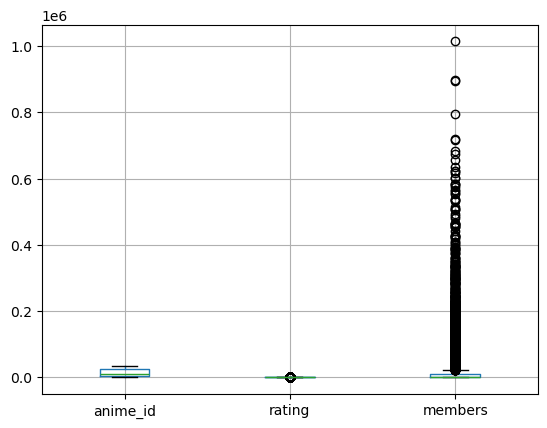

In [13]:
import matplotlib.pyplot as plt
df.boxplot()
plt.show()

In [15]:
#### outlier capping

def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+ 1.5*IQR

    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(include=['int','float']).columns:

    outlier_capping(df,col)

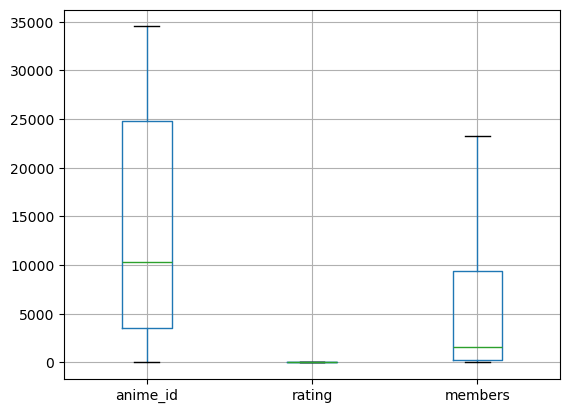

In [16]:
df.boxplot()
plt.show()

In [17]:
# Select relevant features
features_df = df[['genre', 'rating', 'members']].copy()

features_df.head()

,genre,rating,members
0,"Drama, Romance, School, Supernatural",9.075,23255.0
1,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.075,23255.0
2,"Action, Comedy, Historical, Parody, Samurai, S...",9.075,23255.0
3,"Sci-Fi, Thriller",9.075,23255.0
4,"Action, Comedy, Historical, Parody, Samurai, S...",9.075,23255.0


In [18]:
from sklearn.preprocessing import MultiLabelBinarizer

# Split genres into list
features_df['genre'] = features_df['genre'].apply(lambda x: x.split(','))

# Apply MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(features_df['genre'])

# Convert to DataFrame
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

genre_df.head()

,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,Harem,...,Shounen,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
# Select numerical features
numeric_df = features_df[['rating', 'members']].reset_index(drop=True)

# Combine genre + numerical features
final_features = pd.concat([genre_df, numeric_df], axis=1)

final_features.head()

,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,Harem,...,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,rating,members
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9.075,23255.0
1,1,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,9.075,23255.0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9.075,23255.0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9.075,23255.0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9.075,23255.0


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

final_features[['rating', 'members']] = scaler.fit_transform(
    final_features[['rating', 'members']]
)

final_features.head()

,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,Harem,...,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,rating,members
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,1.0
1,1,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1.0,1.0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,1.0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,1.0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,1.0


In [21]:
print("Final Feature Shape:", final_features.shape)

Final Feature Shape: (12294, 85)


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
cosine_sim = cosine_similarity(final_features)

# Convert to DataFrame (optional for readability)
cosine_sim_df = pd.DataFrame(cosine_sim, index=df['name'], columns=df['name'])

cosine_sim_df.head()

name,Kimi no Na wa.,Fullmetal Alchemist: Brotherhood,Gintama°,Steins;Gate,Gintama&#039;,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Gakuen Koukou,Hunter x Hunter (2011),Ginga Eiyuu Densetsu,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare,Gintama&#039;: Enchousen,...,Super Erotic Anime,Taimanin Asagi 3,Teleclub no Himitsu,Tenshi no Habataki Jun,The Satisfaction,Toushindai My Lover: Minami tai Mecha-Minami,Under World,Violence Gekiga David no Hoshi,Violence Gekiga Shin David no Hoshi: Inma Densetsu,Yasuji no Pornorama: Yacchimae!!
name,,,,,,,,,,,,,,,,,,,,,
Kimi no Na wa.,1.000000,0.272166,0.272166,0.408248,0.272166,0.462910,0.333333,0.500000,0.272166,0.272166,...,0.038396,0.345527,0.056261,0.030297,0.032873,0.016065,0.025988,0.073766,0.080639,0.115432
Fullmetal Alchemist: Brotherhood,0.272166,1.000000,0.444444,0.333333,0.444444,0.503953,0.680414,0.408248,0.444444,0.444444,...,0.031350,0.097431,0.045937,0.024737,0.026841,0.013117,0.021219,0.060229,0.065842,0.094250
Gintama°,0.272166,0.444444,1.000000,0.333333,1.000000,0.377964,0.544331,0.408248,1.000000,1.000000,...,0.031350,0.097431,0.045937,0.024737,0.026841,0.013117,0.021219,0.060229,0.065842,0.094250
Steins;Gate,0.408248,0.333333,0.333333,1.000000,0.333333,0.377964,0.408248,0.408248,0.333333,0.333333,...,0.047025,0.146146,0.068905,0.037106,0.040261,0.019676,0.031828,0.090344,0.098763,0.141375
Gintama&#039;,0.272166,0.444444,1.000000,0.333333,1.000000,0.377964,0.544331,0.408248,1.000000,1.000000,...,0.031350,0.097431,0.045937,0.024737,0.026841,0.013117,0.021219,0.060229,0.065842,0.094250


In [23]:
def recommend_anime(anime_name, top_n=10, threshold=0.5):
    if anime_name not in cosine_sim_df.index:
        return "Anime not found!"
    
    # Get similarity scores
    sim_scores = cosine_sim_df[anime_name]
    
    # Remove itself
    sim_scores = sim_scores.drop(anime_name)
    
    # Apply threshold
    sim_scores = sim_scores[sim_scores >= threshold]
    
    # Sort descending
    sim_scores = sim_scores.sort_values(ascending=False)
    
    # Return top N
    return sim_scores.head(top_n)

In [24]:
recommend_anime("Naruto", top_n=10, threshold=0.5)

name
Naruto: Shippuuden                                                           0.999955
Boruto: Naruto the Movie                                                     0.999871
Naruto x UT                                                                  0.999856
Naruto: Shippuuden Movie 4 - The Lost Tower                                  0.999786
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono                        0.999737
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!    0.998638
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi                      0.994785
Naruto Shippuuden: Sunny Side Battle                                         0.985553
Katekyo Hitman Reborn!                                                       0.919805
Dragon Ball Z                                                                0.877333
Name: Naruto, dtype: float64

In [25]:
# Low threshold → more recommendations
print("Threshold 0.3")
print(recommend_anime("Naruto", threshold=0.3))

# Medium threshold
print("\nThreshold 0.5")
print(recommend_anime("Naruto", threshold=0.5))

# High threshold → fewer but more similar
print("\nThreshold 0.7")
print(recommend_anime("Naruto", threshold=0.7))

Threshold 0.3
name
Naruto: Shippuuden                                                           0.999955
Boruto: Naruto the Movie                                                     0.999871
Naruto x UT                                                                  0.999856
Naruto: Shippuuden Movie 4 - The Lost Tower                                  0.999786
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono                        0.999737
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!    0.998638
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi                      0.994785
Naruto Shippuuden: Sunny Side Battle                                         0.985553
Katekyo Hitman Reborn!                                                       0.919805
Dragon Ball Z                                                                0.877333
Name: Naruto, dtype: float64

Threshold 0.5
name
Naruto: Shippuuden                                                      

### Interview Questions: